# Who Does Your Writing Sound Like?
Runs the whole project: downloads the books, trains the model, and launches the app.

**Before running:** add your free Groq API key as a Colab Secret named `GROQ_API_KEY`.
Then click Runtime → Run all.

In [1]:
!git clone https://github.com/mahi-sharmas/MUJ-DS-23FE10CDS00276.git
%cd MUJ-DS-23FE10CDS00276
!pip install -q -r requirements.txt

Cloning into 'MUJ-DS-23FE10CDS00276'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 79 (delta 35), reused 59 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 89.13 KiB | 736.00 KiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/MUJ-DS-23FE10CDS00276
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 4.9 MB/s eta 0:00:00


In [2]:
import os
from google.colab import userdata

try:
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
    print("Groq key loaded.")
except Exception:
    print("No GROQ_API_KEY secret found - the app will still work, but without the AI explanation.")

Groq key loaded.


In [3]:
!python -m src.data

austen     train   1342  253 chunks  Pride and Prejudice
austen     train    158  314 chunks  Emma
austen     train    161  237 chunks  Sense and Sensibility
austen     test     105  166 chunks  Persuasion
dickens    train    730  315 chunks  Oliver Twist
dickens    train   1400  368 chunks  Great Expectations
dickens    train    786  206 chunks  Hard Times
dickens    test      98  271 chunks  A Tale of Two Cities
twain      train     74  140 chunks  The Adventures of Tom Sawyer, Complete
twain      train     86  235 chunks  A Connecticut Yankee in King Arthur's Court
twain      train   1837  139 chunks  The Prince and the Pauper
twain      test      76  221 chunks  Adventures of Huckleberry Finn
doyle      train    244   86 chunks  A Study in Scarlet
doyle      train   2097   85 chunks  The Sign of the Four
doyle      train    139  151 chunks  The Lost World
doyle      test    2852  118 chunks  The Hound of the Baskervilles
hardy      train    110  299 chunks  Tess of the d'Urberville

style_only         accuracy=0.743  macro-F1=0.742
style_plus_tfidf   accuracy=0.843  macro-F1=0.841

              precision    recall  f1-score   support

      austen      0.921     0.875     0.897        40
      bronte      0.881     0.925     0.902        40
      conrad      0.895     0.850     0.872        40
     dickens      0.636     0.700     0.667        40
       doyle      0.870     1.000     0.930        40
       eliot      0.906     0.725     0.806        40
       hardy      0.745     0.875     0.805        40
   stevenson      0.929     0.650     0.765        40
       twain      0.818     0.900     0.857        40
       wells      0.902     0.925     0.914        40

    accuracy                          0.843       400
   macro avg      0.850     0.843     0.841       400
weighted avg      0.850     0.843     0.841       400

Top style features per author:
austen     fw_very, fw_be, fw_such, fw_her, fw_not
bronte     p_colon, p_semicolon, type_token_ratio, fw_she,

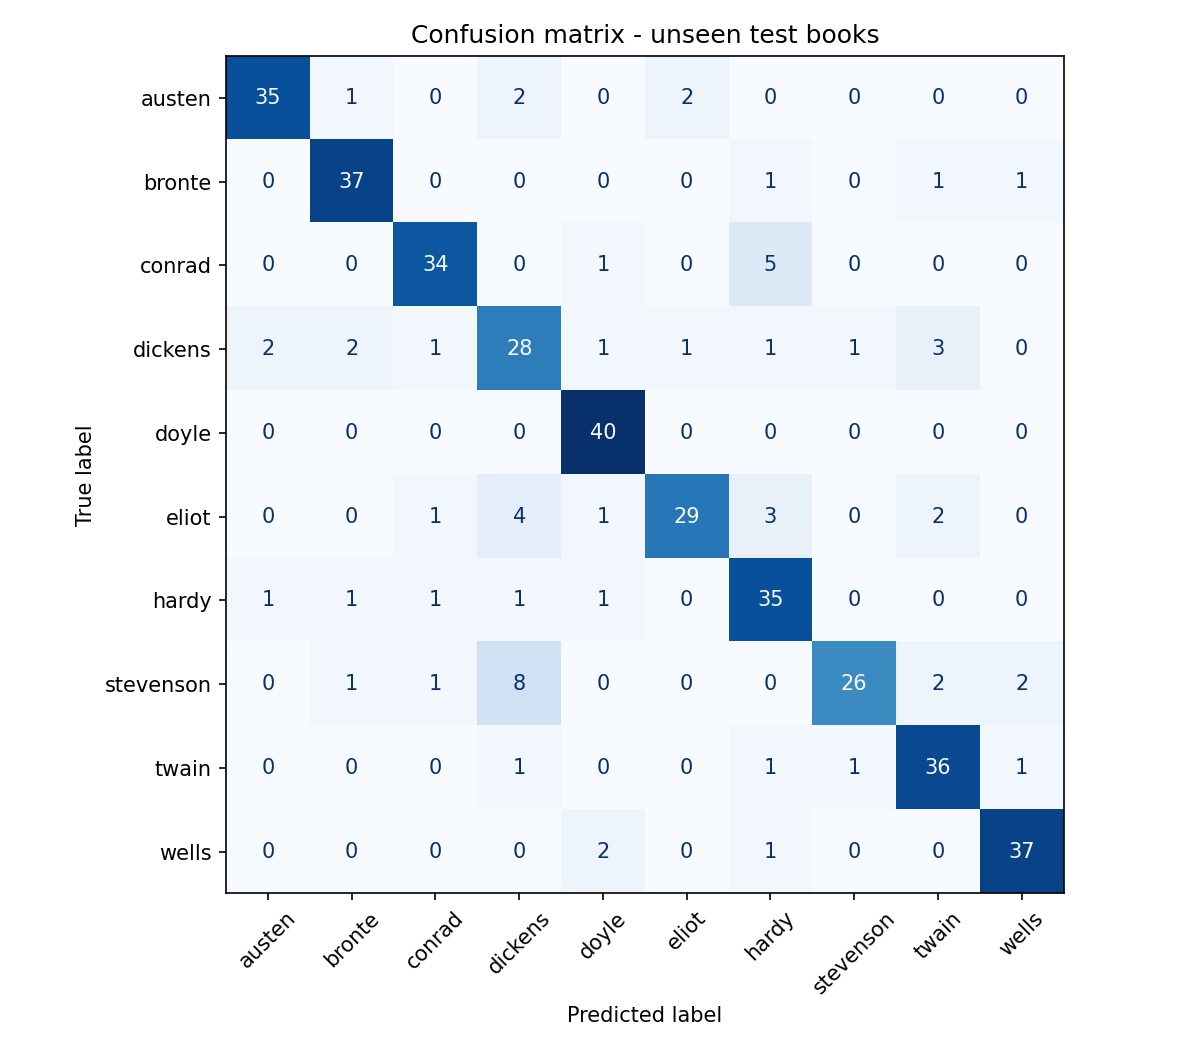

In [4]:
!python -m src.train

from IPython.display import Image, display
display(Image("results/confusion_matrix.png", width=600))

In [5]:
from src.app import build_app
build_app().launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f84edaed4cc856e26f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
